# TwoTank - Stage 5a - Nominal Controller Evaluation

Evaluate the configured controllers on matched scenarios.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_p = Path.cwd()
while not (_p / 'src' / 'sdpc').exists():
    _p = _p.parent
sys.path.insert(0, str(_p / 'src'))

import matplotlib.pyplot as plt
import pandas as pd
import torch

from sdpc.config import load_config
from sdpc.eval import evaluate_twotank_nominal, policy_forward_latency
from sdpc.plotting import plot_states_and_controls
from sdpc.registry import make_system
from sdpc.sindy import load_model
from sdpc.training import load_nn_policy

device = torch.device('cpu')
system = make_system('twotank', device=device)
CONFIGS = Path.cwd().parent / 'configs'
RESULTS = Path.cwd().parent / 'results'
cfg = load_config(CONFIGS / 'eval_nominal.yaml')
print({k: cfg[k] for k in ('n_trajectories', 'nsteps', 'n_references')})
print('DPC-matched loss weights:', cfg['weights'])
print('Online MPC configuration:', cfg['mpc'])

{'n_trajectories': 20, 'nsteps': 1000, 'n_references': 4}


## Load the two learned policies

Restore the required checkpoints.


In [ ]:
from sdpc.io import find_policy_checkpoint, find_nn_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
sparse_policy = load_model(policy_path, device=device).eval()

nn_path = find_nn_checkpoint(RESULTS, cfg)
nn_policy = load_nn_policy(system, nn_path, cfg, device=device)
print('SD-DPC:', policy_path)
print('NN-DPC:', nn_path)

## Policy-only inference benchmark

Inspect policy performance.


In [3]:
probe_x = torch.zeros(1, 1, system.nx, device=device)
probe_r = torch.zeros(1, 1, system.nx, device=device)
policy_latencies = {
    name: policy_forward_latency(
        policy, probe_x, probe_r, **cfg['inference_benchmark']
    )
    for name, policy in [('sd_dpc', sparse_policy), ('nn_dpc', nn_policy)]
}
policy_only = pd.DataFrame.from_dict(policy_latencies, orient='index')
policy_only.index.name = 'method'
policy_only['relative_to_sd'] = (
    policy_only['policy_forward_per_step_us']
    / policy_only.loc['sd_dpc', 'policy_forward_per_step_us']
)
display(policy_only[['policy_forward_per_step_us', 'policy_forward_per_step_ms', 'relative_to_sd']])

,policy_forward_per_step_us,policy_forward_per_step_ms,relative_to_sd
method,,,
sd_dpc,63.384936,0.063385,1.000000
nn_dpc,42.998300,0.042998,0.678368


## Run the configured nominal trajectories

Run the matched nominal evaluation.


In [4]:
nominal_out = evaluate_twotank_nominal(
    system, sparse_policy, nn_policy, cfg, device, progress=True,
    policy_latencies=policy_latencies,
)
scenario = nominal_out['scenarios']
assert scenario['xn'].shape == (cfg['n_trajectories'], 1, system.nx)
assert scenario['r'].shape == (cfg['n_trajectories'], cfg['nsteps'] + 1, system.nx)
assert torch.all(scenario['r'][..., 0] == scenario['r'][..., 1])
print('Distinct initial states:', torch.unique(scenario['xn'][:, 0], dim=0).shape[0])

MPC trajectory 1/20
  Solve_Succeeded: 148 iterations, 15.896 s
MPC trajectory 2/20
  Solve_Succeeded: 17 iterations, 4.596 s
MPC trajectory 3/20
  Solve_Succeeded: 37 iterations, 6.378 s
MPC trajectory 4/20
  Solve_Succeeded: 20 iterations, 5.127 s
MPC trajectory 5/20
  Solve_Succeeded: 27 iterations, 5.708 s
MPC trajectory 6/20
  Solve_Succeeded: 91 iterations, 11.603 s
MPC trajectory 7/20
  Solve_Succeeded: 48 iterations, 7.614 s
MPC trajectory 8/20
  Solve_Succeeded: 55 iterations, 8.314 s
MPC trajectory 9/20
  Solve_Succeeded: 52 iterations, 8.016 s
MPC trajectory 10/20
  Solve_Succeeded: 53 iterations, 8.006 s
MPC trajectory 11/20
  Solve_Succeeded: 31 iterations, 6.125 s
MPC trajectory 12/20
  Solve_Succeeded: 20 iterations, 5.561 s
MPC trajectory 13/20
  Solve_Succeeded: 16 iterations, 4.740 s
MPC trajectory 14/20
  Solve_Succeeded: 23 iterations, 5.540 s
MPC trajectory 15/20
  Solve_Succeeded: 20 iterations, 5.096 s
MPC trajectory 16/20
  Solve_Succeeded: 48 iterations, 7.710 

## Aggregate metrics

Compare performance and runtime metrics.


In [5]:
summary = pd.DataFrame.from_dict(nominal_out['summary'], orient='index')
summary.index.name = 'method'
summary_columns = [
    'tracking_mse_mean', 'tracking_mse_std',
    'control_smoothness_rms_mean', 'max_du_l2_mean',
    'num_state_violations_mean', 'num_control_rate_violations_mean',
    'min_safety_margin_mean', 'policy_forward_per_step_us_mean',
    'policy_forward_per_step_ms_mean',
    'mpc_solve_time_s_mean', 'mpc_solve_per_step_ms_mean',
    'mpc_setup_time_s_mean', 'mpc_iterations_per_solve_mean',
    'mpc_max_iterations_per_solve_mean', 'mpc_horizon_mean',
]
display(summary.reindex(columns=summary_columns))

,tracking_mse_mean,tracking_mse_std,control_smoothness_rms_mean,max_du_l2_mean,num_state_violations_mean,num_control_rate_violations_mean,min_safety_margin_mean,policy_forward_per_step_us_mean,policy_forward_per_step_ms_mean,mpc_solve_time_s_mean,mpc_solve_per_step_ms_mean
method,,,,,,,,,,,
mpc,0.002315,0.001635,0.032520,0.483496,0.0,0.0,0.154949,NaN,NaN,7.785813,7.785813
sd_dpc,0.005256,0.004051,0.030160,0.671360,0.0,0.0,0.116453,63.384936,0.063385,NaN,NaN
nn_dpc,0.005204,0.004077,0.063365,0.752711,0.1,0.0,0.067008,42.998300,0.042998,NaN,NaN


## Violations summarized per trajectory

Visualize the closed-loop response.


In [6]:
nominal_violations = pd.DataFrame.from_dict(nominal_out['violations'], orient='index')
nominal_violations.index.name = 'method'
display(nominal_violations)

,n_trajectories,trajectories_with_violations,trajectory_violation_fraction,total_violations,mean_violations_per_trajectory,median_violations_per_trajectory,max_violations_per_trajectory,total_state_violations,total_control_rate_violations
method,,,,,,,,,
mpc,20,0,0.00,0,0.0,0.0,0,0,0
sd_dpc,20,0,0.00,0,0.0,0.0,0,0,0
nn_dpc,20,1,0.05,2,0.1,0.0,2,2,0


## Per-trajectory results

Visualize the closed-loop response.


In [7]:
nominal_rows = pd.DataFrame([
    row for rows in nominal_out['per_trajectory'].values() for row in rows
])
display(nominal_rows.head())

,tracking_mse,control_cost_l1,control_cost_l2,control_smoothness_rms,mean_du_l2,max_du_l2,control_total_variation_l1,violation_magnitude,num_state_violations,num_violations,...,reference_0,reference_1,reference_2,reference_3,method,trajectory,policy_forward_per_step_s,policy_forward_per_step_ms,policy_forward_per_step_us,batched_rollout_wall_time_s
0,0.001834,343.341125,127.989243,0.028836,0.003597,0.385873,4.041083,0.0,0,0,...,0.359142,0.743149,0.484944,0.285481,mpc,0,NaN,NaN,NaN,NaN
1,0.001685,327.677551,114.900986,0.029430,0.003775,0.412385,4.598630,0.0,0,0,...,0.306710,0.544725,0.578745,0.308481,mpc,1,NaN,NaN,NaN,NaN
2,0.000996,358.938965,136.544067,0.035302,0.004557,0.551247,5.690527,0.0,0,0,...,0.559692,0.279559,0.494404,0.651963,mpc,2,NaN,NaN,NaN,NaN
3,0.000138,363.016205,136.061859,0.041281,0.005094,0.571868,6.299163,0.0,0,0,...,0.470488,0.399646,0.488176,0.622638,mpc,3,NaN,NaN,NaN,NaN
4,0.002727,364.629700,141.180542,0.031646,0.004248,0.447152,5.156353,0.0,0,0,...,0.326723,0.519010,0.729673,0.496945,mpc,4,NaN,NaN,NaN,NaN


## First matched scenario

Compare the executed trajectories.


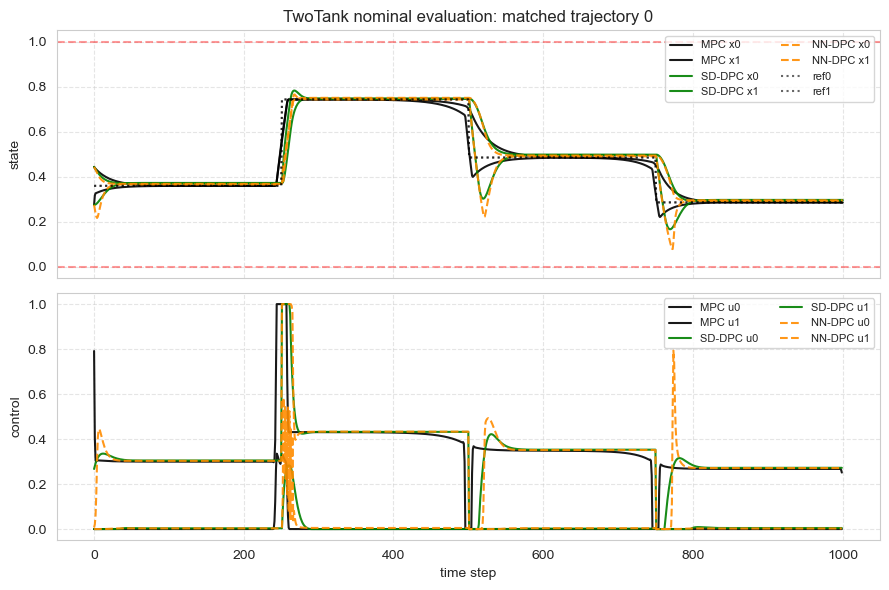

In [8]:
examples = nominal_out['examples']
fig, axes = plot_states_and_controls(
    [
        {'x': examples['mpc']['x_traj'], 'u': examples['mpc']['u_traj'],
         'label': 'MPC', 'color': 'black'},
        {'x': examples['sd_dpc']['x_traj'], 'u': examples['sd_dpc']['u_traj'],
         'label': 'SD-DPC', 'color': 'green'},
        {'x': examples['nn_dpc']['x_traj'], 'u': examples['nn_dpc']['u_traj'],
         'label': 'NN-DPC', 'color': 'darkorange', 'linestyle': '--'},
    ],
    r_traj=scenario['r'][:1], xmin=system.xmin, xmax=system.xmax,
    title='TwoTank: online MPC vs SD-DPC vs NN-DPC, matched 1000-step scenario',
)
switch_steps = (scenario['r'][0, 1:] != scenario['r'][0, :-1]).any(dim=1).nonzero().flatten() + 1
for ax in axes:
    for step in switch_steps.tolist():
        ax.axvline(step, color='0.55', linestyle='--', linewidth=0.8, alpha=0.7)
figure_dir = RESULTS / 'eval' / f"nominal_{cfg['n_trajectories']}x{cfg['nsteps']}"
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / 'trajectory_0_mpc_sd_nn.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Reference switches:', switch_steps.tolist())
print('Saved figure:', figure_path)
plt.show()

example_columns = [
    'tracking_mse', 'control_cost_l1', 'control_cost_l2',
    'control_smoothness_rms', 'mean_du_l2', 'max_du_l2',
    'control_total_variation_l1', 'num_state_violations',
    'num_control_rate_violations', 'min_state_margin',
    'min_control_rate_margin', 'min_safety_margin',
    'policy_forward_per_step_us', 'mpc_solve_per_step_ms',
    'mpc_solve_time_s', 'mpc_setup_time_s', 'mpc_iterations_per_solve',
]
example_metrics = (
    nominal_rows[nominal_rows['trajectory'] == 0]
    .set_index('method')
    .reindex(columns=example_columns)
)
display(example_metrics)
example_metrics.to_csv(figure_dir / 'trajectory_0_metrics.csv')

## Save tables

Save the generated artifacts.


In [9]:
out_dir = RESULTS / 'eval' / f"nominal_{cfg['n_trajectories']}x{cfg['nsteps']}"
out_dir.mkdir(parents=True, exist_ok=True)
summary.to_csv(out_dir / 'summary.csv')
nominal_violations.to_csv(out_dir / 'violation_summary.csv')
nominal_rows.to_csv(out_dir / 'per_trajectory.csv', index=False)
print('Saved to', out_dir)

Saved to /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/TwoTank/results/eval/nominal_20x1000
